# Importance-weight decay sensitivity for the Chesapeake Bay adaptive controller.

Larger sigma_weight means a slower Gaussian decline away from the rated
salinity and therefore more spatially even importance weights.  The study
keeps every physical/model parameter fixed and asks whether the imposed
0.5 m/s floor remains active in each re-optimization.

<!-- # Run from this directory:
#   julia --project=../ importance_weight_decay_sensitivity.jl -->
<!-- # Optional: SENSITIVITY_HOURS=72 SIGMA_WEIGHTS=1.5,2.0,3.0,4.5 julia --project=../ importance_weight_decay_sensitivity.jl -->


In [1]:
ENV["GKSwstype"] = "100"  # non-interactive plots

include("../src/cbdata.jl")
include("../src/ASVGeometry.jl")
include("../src/clarity.jl")
include("../src/IVESim.jl")

using .CBOFSData, .ASVGeometry, .Clarity, .IVESim
using Dates, Statistics, DataFrames, JLD2, Plots, Printf


In [2]:
const SPEED_FLOOR = 0.0
const FLOOR_TOL = 1e-3
const U_NOMINAL = 1.75
const ALPHA_CLARITY = 0.001
const SIGMA_SENSING = 1500.0
const NPTS = 100                     # screening resolution; use 200 for a final confirmation
const DT_STEP = 60.0

parse_float_list(text) = parse.(Float64, split(text, ','))
sigma_weights = parse_float_list(get(ENV, "SIGMA_WEIGHTS", "1.5,2.0,3.0,4.5,6.0"))
max_hours = parse(Float64, get(ENV, "SENSITIVITY_HOURS", "48"))

48.0

In [3]:
"Summarize whether an optimized segment profile is constrained by the speed floor."
function floor_metrics(u, ds; floor=SPEED_FLOOR, tol=FLOOR_TOL)
    dt = ds ./ u
    active = u .<= floor + tol
    return (
        min_speed_mps = minimum(u),
        floor_active_segments = count(active),
        floor_active_fraction = mean(active),
        floor_active_time_fraction = sum(dt[active]) / sum(dt),
        lap_time_hr = sum(dt) / 3600,
    )
end

"Run the dynamic simulation for one salinity-weight width and log every optimization." 
function run_case(frames, sigma_weight; max_hours=max_hours, speed_floor=SPEED_FLOOR, optimize=true)
    vehicle = VehicleParams(U_NOMINAL, 24 * 3600.0)
    P_in = vehicle.kh + vehicle.km * U_NOMINAL^3
    lon_path, lat_path, s_vec = discretize_polyline(transect_lon_shifted, transect_lat_shifted, NPTS)
    path_length = s_vec[end]
    N = NPTS - 1
    ds = path_length / N

    start_time = frames[1].dt
    end_time = min(frames[end].dt, start_time + Millisecond(round(Int, max_hours * 3600_000)))
    sim_times = collect(start_time:Minute(1):end_time)
    frame_times = [f.dt for f in frames]
    frame_index(t) = argmin(abs.(Dates.value.(frame_times .- t)))

    # Cartesian path coordinates used by the sensing model.
    earth_radius = 6_371_000.0
    scale_x = earth_radius * cos(deg2rad(mean(lat_path)))
    X = deg2rad.(lon_path) .* scale_x
    Y = deg2rad.(lat_path) .* earth_radius

    q = zeros(NPTS)
    weights = ones(NPTS)
    u = optimize ? optimize_lap_speeds_full_spatiotemporal(
        weights, q, N, ds, P_in, ALPHA_CLARITY, vehicle, SIGMA_SENSING;
        speed_floor=speed_floor,
    ) : fill(U_NOMINAL, N)

    rows = DataFrame(sigma_weight=Float64[], speed_floor=Float64[], lap=Int[], kind=String[],
        weight_mean=Float64[], weight_std=Float64[], weight_cv=Float64[],
        min_speed_mps=Float64[], floor_active_segments=Int[],
        floor_active_fraction=Float64[], floor_active_time_fraction=Float64[], lap_time_hr=Float64[])
    profiles = DataFrame(sigma_weight=Float64[], speed_floor=Float64[], lap=Int[], kind=String[], segment=Int[],
        distance_m=Float64[], speed_mps=Float64[], importance_weight=Float64[])
    function record!(lap, kind, profile)
        m = floor_metrics(profile, ds; floor=speed_floor)
        push!(rows, (sigma_weight, speed_floor, lap, kind, mean(weights), std(weights), std(weights)/mean(weights),
            m.min_speed_mps, m.floor_active_segments, m.floor_active_fraction,
            m.floor_active_time_fraction, m.lap_time_hr))
        for i in eachindex(profile)
            push!(profiles, (sigma_weight, speed_floor, lap, kind, i, (i - 0.5) * ds, profile[i], weights[i]))
        end
    end
    record!(1, "uniform", u)

    position_total = 0.0
    previous_lap = 1
    salinity_buffer = Float64[]
    position_buffer = Float64[]
    cached_frame = -1
    total_reward = 0.0
    total_unweighted_clarity = 0.0
    lon_v = lat_v = salt_v = nothing

    for t in sim_times
        lap = floor(Int, position_total / path_length) + 1
        position_mod = mod(position_total, path_length)
        if lap > previous_lap
            weights = calculate_target_weights(salinity_buffer, position_buffer, s_vec, NPTS;
                sigma_weight=sigma_weight)
            if optimize
                u = optimize_lap_speeds_full_spatiotemporal_warm(
                    weights, q, u, N, ds, P_in, ALPHA_CLARITY, vehicle, SIGMA_SENSING;
                    speed_floor=speed_floor,
                )
                record!(lap, "adaptive", u)
            else
                record!(lap, "constant", u)
            end
            empty!(salinity_buffer); empty!(position_buffer)
            previous_lap = lap
        end

        idx = frame_index(t)
        if idx != cached_frame
            lon_v, lat_v, salt_v = load_surface_salinity(frames[idx].file)
            cached_frame = idx
        end
        lon_r, lat_r = get_2d_position(position_mod, s_vec, lon_path, lat_path)
        push!(salinity_buffer, sample_salinity(lon_r, lat_r, lon_v, lat_v, salt_v))
        push!(position_buffer, position_mod)

        # Match the full simulation's 0.25-s sensing/propagation update.
        elapsed = 0.0
        position_local = position_total
        while elapsed < DT_STEP
            h = min(0.25, DT_STEP - elapsed)
            s_local = mod(position_local, path_length)
            segment = min(floor(Int, s_local / ds) + 1, N)
            Xr, Yr = get_2d_position(s_local, s_vec, X, Y)
            sensing = sensing_function.((X .- Xr).^2 .+ (Y .- Yr).^2; S_0=0.005, sigma=SIGMA_SENSING)
            q .= update_clarity_rk4.(q, sensing, h; alpha=ALPHA_CLARITY)
            position_local += u[segment] * h
            elapsed += h
        end
        position_total = position_local
        total_reward += sum(weights .* q) * DT_STEP
        total_unweighted_clarity += sum(q) * DT_STEP
    end
    duration_s = length(sim_times) * DT_STEP
    return (; metrics=rows, profiles, total_reward, mean_reward=total_reward / duration_s,
        total_unweighted_clarity, mean_unweighted_clarity=total_unweighted_clarity / duration_s)
end


run_case

In [4]:

frames = discover_files("./datafiles")
@info "Importance-weight sensitivity" max_hours sigma_weights speed_floor=SPEED_FLOOR npts=NPTS
all_rows = DataFrame()
all_profiles = DataFrame()
for sigma_weight in sigma_weights
    @info "Running case" sigma_weight
    result = run_case(frames, sigma_weight)
    append!(all_rows, result.metrics)
    append!(all_profiles, result.profiles)
end

# Adaptive rows are the direct answer to the PI's question. Aggregate across
# re-optimizations rather than across minute-by-minute samples of a profile.
adaptive = filter(:kind => ==("adaptive"), all_rows)
# A short smoke test may not finish its initial lap. Preserve that result instead
# of failing during aggregation, but label it so it is not mistaken for evidence
# about adaptive importance weights.
analysis_rows = isempty(adaptive) ? all_rows : adaptive
analysis_kind = isempty(adaptive) ? "initial uniform optimization only" : "adaptive re-optimizations"
isempty(adaptive) && @warn "No lap completed in this run; increase SENSITIVITY_HOURS before drawing conclusions about sigma_weight."
summary = combine(groupby(analysis_rows, :sigma_weight),
    nrow => :adaptive_reoptimizations,
    :floor_active_fraction => mean => :mean_floor_active_fraction,
    :floor_active_fraction => maximum => :max_floor_active_fraction,
    :floor_active_time_fraction => mean => :mean_floor_active_time_fraction,
    :floor_active_segments => mean => :mean_floor_active_segments,
    :min_speed_mps => minimum => :minimum_speed_seen_mps,
    :weight_cv => mean => :mean_weight_cv,
)
sort!(summary, :sigma_weight)
println("\n=== Adaptive speed-floor sensitivity summary ===")
show(summary, allrows=true, allcols=true); println()



┌ Info: Importance-weight sensitivity
│   max_hours = 48.0
│   sigma_weights = [1.5, 2.0, 3.0, 4.5, 6.0]
│   speed_floor = 0.0
│   npts = 100
└ @ Main /run/media/kmgovind/SharedDrive/Research/acc27_periodic_ive/code/chesapeake_bay/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:3
┌ Info: Running case
│   sigma_weight = 1.5
└ @ Main /run/media/kmgovind/SharedDrive/Research/acc27_periodic_ive/code/chesapeake_bay/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:7



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Success! Speeds optimized.
Success! Speeds optimized.


┌ Info: Running case
│   sigma_weight = 2.0
└ @ Main /run/media/kmgovind/SharedDrive/Research/acc27_periodic_ive/code/chesapeake_bay/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:7


Success! Speeds optimized.
Success! Speeds optimized.


┌ Info: Running case
│   sigma_weight = 3.0
└ @ Main /run/media/kmgovind/SharedDrive/Research/acc27_periodic_ive/code/chesapeake_bay/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:7


Success! Speeds optimized.
Success! Speeds optimized.


┌ Info: Running case
│   sigma_weight = 4.5
└ @ Main /run/media/kmgovind/SharedDrive/Research/acc27_periodic_ive/code/chesapeake_bay/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:7


Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.


┌ Info: Running case
│   sigma_weight = 6.0
└ @ Main /run/media/kmgovind/SharedDrive/Research/acc27_periodic_ive/code/chesapeake_bay/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:7


Success! Speeds optimized.
Success! Speeds optimized.

=== Adaptive speed-floor sensitivity summary ===
5×8 DataFrame
 Row │ sigma_weight  adaptive_reoptimizations  mean_floor_active_fraction  max_floor_active_fraction  mean_floor_active_time_fraction  mean_floor_active_segments  minimum_speed_seen_mps  mean_weight_cv 
     │ Float64       Int64                     Float64                     Float64                    Float64                          Float64                     Float64                 Float64        
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │          1.5                         1                         0.0                        0.0                              0.0                         0.0               0.0100026        1.17652
   2 │          2.0                         1                         0.

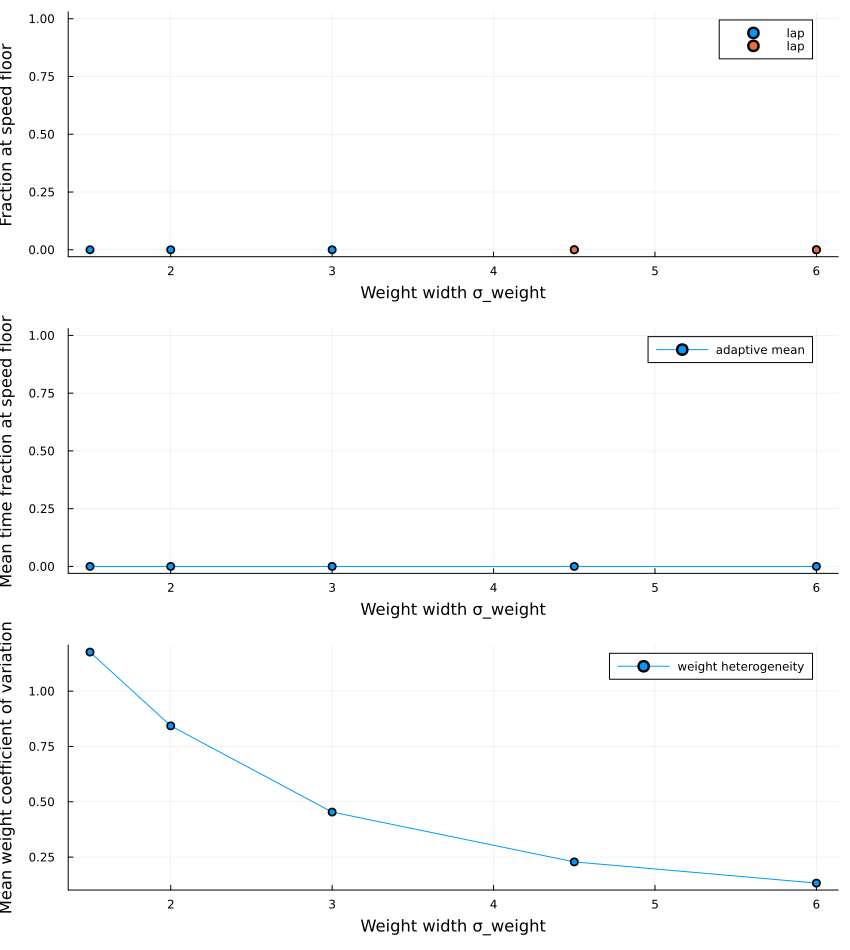

In [5]:
p_floor = plot(
    analysis_rows.sigma_weight,
    analysis_rows.floor_active_fraction,
    group=analysis_rows.lap,
    seriestype=:scatter,
    xlabel="Weight width σ_weight",
    ylabel="Fraction at speed floor",
    label="lap",
)

p_time = plot(
    summary.sigma_weight,
    summary.mean_floor_active_time_fraction,
    marker=:circle,
    xlabel="Weight width σ_weight",
    ylabel="Mean time fraction at speed floor",
    label="adaptive mean",
)

p_cv = plot(
    summary.sigma_weight,
    summary.mean_weight_cv,
    marker=:circle,
    xlabel="Weight width σ_weight",
    ylabel="Mean weight coefficient of variation",
    label="weight heterogeneity",
)
plot(p_floor, p_time, p_cv, layout=(3, 1), size=(850, 950))


## Speed-allocation profiles

This reproduces the two-panel comparison: the final adaptive speed allocation above, and the target-weight profile that generated it below. Run the simulation cell first.

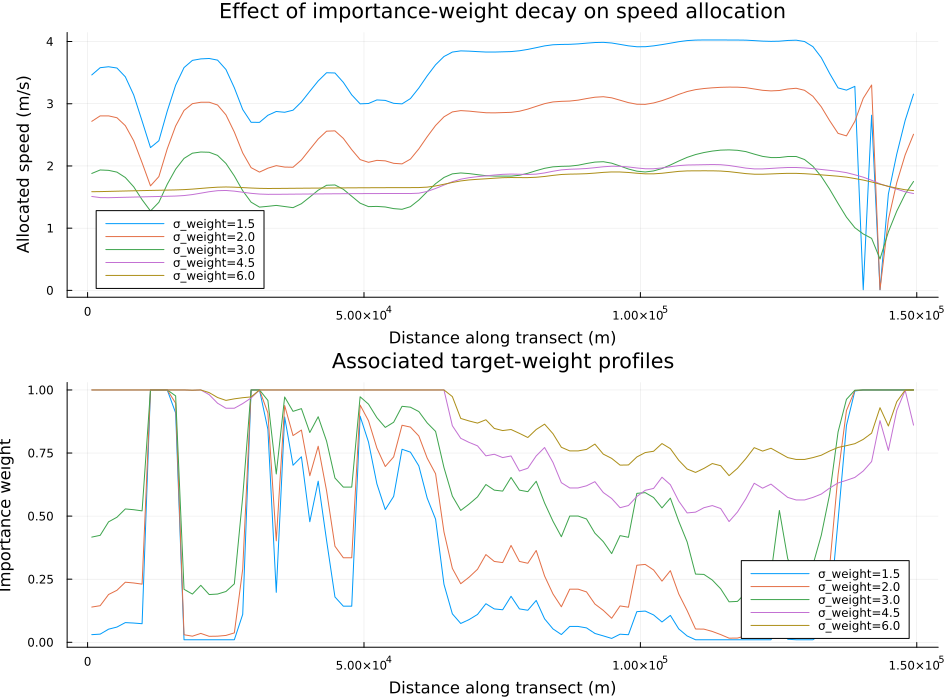

In [15]:
p_speed = plot(xlabel="Distance along transect (m)", ylabel="Allocated speed (m/s)",
    title="Effect of importance-weight decay on speed allocation", legend=:bottomleft)
p_weight = plot(xlabel="Distance along transect (m)", ylabel="Importance weight",
    title="Associated target-weight profiles", legend=:bottomright)

for sigma_weight in sort(unique(all_profiles.sigma_weight))
    profile = filter(row -> row.sigma_weight == sigma_weight && row.kind == "adaptive", all_profiles)
    isempty(profile) && continue
    profile = filter(:lap => ==(maximum(profile.lap)), profile)
    plot!(p_speed, profile.distance_m, profile.speed_mps, label="σ_weight=$(sigma_weight)")
    plot!(p_weight, profile.distance_m, profile.importance_weight, label="σ_weight=$(sigma_weight)")
end

plot(p_speed, p_weight, layout=(2, 1), size=(950, 700))
savefig("importance_weight_decay_effect.png")
plot!()

In [11]:
zero_floor_sigmas = sort(unique(
    analysis_rows.sigma_weight[analysis_rows.min_speed_mps .<= FLOOR_TOL]
))

println("Sigma-weight strategies that hit the speed floor:")
println(zero_floor_sigmas)

Sigma-weight strategies that hit the speed floor:
Float64[]


In [12]:
minimum_speeds = combine(
    groupby(analysis_rows, :sigma_weight),
    :min_speed_mps => minimum => :minimum_speed_mps,
)

sort!(minimum_speeds, :sigma_weight)
show(minimum_speeds, allrows=true, allcols=true)

5×2 DataFrame
 Row │ sigma_weight  minimum_speed_mps 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │          1.5          0.0100026
   2 │          2.0          0.0100014
   3 │          3.0          0.504041
   4 │          4.5          1.44959
   5 │          6.0          1.58028

## Does a lower floor remove saturation without sacrificing clarity?

For `σ_weight = 1.5` and `2.0`, this cell sweeps the imposed floor from 0.50 to 0.01 m/s. For each setting it reports the time-integrated weighted clarity reward, its percent improvement over a constant-speed run using the same adaptive target weights, and whether the *new* floor is active. `0.01 m/s` is the vehicle model's remaining numerical/physical lower limit.

In [9]:
test_sigmas = [1.5, 2.0]
test_floors = [0.50, 0.25, 0.10, 0.05, 0.01, 0.0]

floor_reward = DataFrame(
    sigma_weight=Float64[], speed_floor_mps=Float64[],
    total_weighted_reward=Float64[], mean_weighted_reward=Float64[],
    reward_improvement_pct=Float64[], minimum_speed_mps=Float64[],
    mean_floor_active_fraction=Float64[], mean_floor_active_time_fraction=Float64[],
    adaptive_reoptimizations=Int[],
)

for sigma_weight in test_sigmas
    # Fair baseline: the same target-weight update rule, but a fixed 1.75 m/s allocation.
    constant = run_case(frames, sigma_weight; max_hours=max_hours, optimize=false)
    for speed_floor in test_floors
        optimized = run_case(frames, sigma_weight; max_hours=max_hours, speed_floor=speed_floor)
        adaptive_metrics = filter(:kind => ==("adaptive"), optimized.metrics)
        @assert !isempty(adaptive_metrics) "Increase max_hours so at least one adaptive re-optimization occurs."
        push!(floor_reward, (
            sigma_weight, speed_floor, optimized.total_reward, optimized.mean_reward,
            100 * (optimized.total_reward / constant.total_reward - 1),
            minimum(adaptive_metrics.min_speed_mps),
            mean(adaptive_metrics.floor_active_fraction),
            mean(adaptive_metrics.floor_active_time_fraction), nrow(adaptive_metrics),
        ))
    end
end

floor_reward

Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.
Success! Speeds optimized.


Row,sigma_weight,speed_floor_mps,total_weighted_reward,mean_weighted_reward,reward_improvement_pct,minimum_speed_mps,mean_floor_active_fraction,mean_floor_active_time_fraction,adaptive_reoptimizations
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64
1,1.5,0.5,4.43818e5,2.5675,3.87099,0.500161,0.10101,0.262934,1
2,1.5,0.25,4.47609e5,2.58943,4.75825,0.250052,0.10101,0.478211,1
3,1.5,0.1,4.67005e5,2.70163,9.29753,0.100017,0.0707071,0.642369,1
4,1.5,0.05,4.84254e5,2.80142,13.3346,0.0500087,0.0505051,0.738654,1
5,1.5,0.01,5.11073e5,2.95657,19.6112,0.0100026,0.020202,0.875722,1
6,1.5,0.0,5.11073e5,2.95657,19.6112,0.0100026,0.0,0.0,1
7,2.0,0.5,4.73025e5,2.73646,2.58973,0.500248,0.0707071,0.197468,1
8,2.0,0.25,4.80764e5,2.78123,4.26817,0.250085,0.0606061,0.305848,1
9,2.0,0.1,4.96478e5,2.87214,7.67633,0.100027,0.0505051,0.534508,1


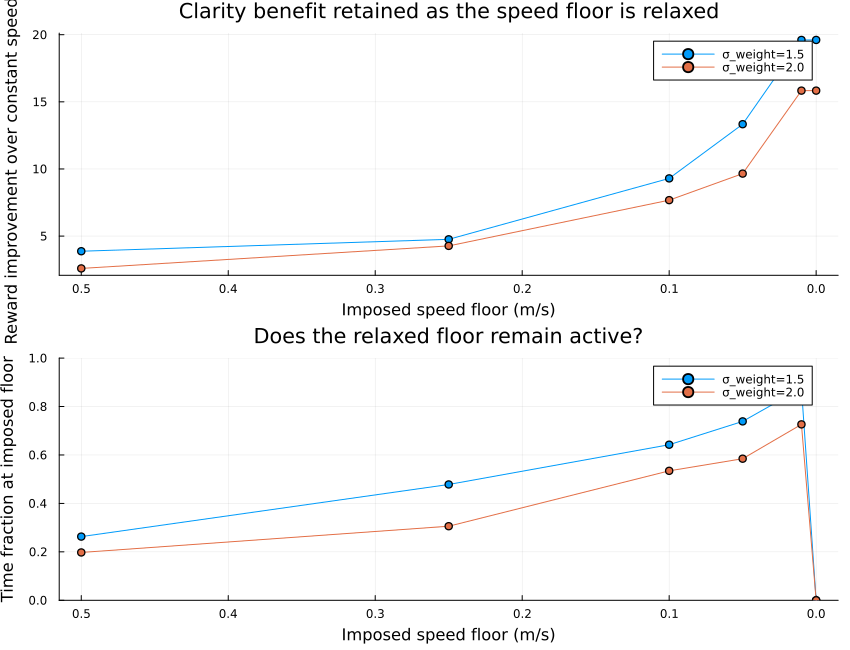

In [10]:
p_reward = plot(xlabel="Imposed speed floor (m/s)", ylabel="Reward improvement over constant speed (%)",
    xflip=true, title="Clarity benefit retained as the speed floor is relaxed")
p_saturation = plot(xlabel="Imposed speed floor (m/s)", ylabel="Time fraction at imposed floor",
    xflip=true, title="Does the relaxed floor remain active?", ylims=(0, 1))
for sigma_weight in test_sigmas
    result = filter(:sigma_weight => ==(sigma_weight), floor_reward)
    plot!(p_reward, result.speed_floor_mps, result.reward_improvement_pct, marker=:circle,
        label="σ_weight=$(sigma_weight)")
    plot!(p_saturation, result.speed_floor_mps, result.mean_floor_active_time_fraction, marker=:circle,
        label="σ_weight=$(sigma_weight)")
end
plot(p_reward, p_saturation, layout=(2, 1), size=(850, 650))